# Programming exercise 2: Time evolution and performance of diagonalization routines

## Goals of the exercise

In the first exercise we calculated the eigenenergies and eigenfunction of a quantum particle in a one-dimensional potential by representing the wave function on a discrete spatial grid and using `np.eigh()` to diagonalize the Hamiltonian matrix. This time we want to use the obtained eigenfunctions to calculate the time evolution for an arbitrary initial state and compare the performance of different routines for exact diagonalization, also exploring the benefits of sparse matrices.

In [1]:
import sys
import os

# add parent directory so Python finds the package
sys.path.append('..')

# load standard libraries

import numpy as np   # arrays, linear algebra, numerical computing
import matplotlib.pyplot as plt  # plotting and visualization
import Comp_Quant_Dynam as cqd  # custom numerics library
import time  # timing execution of code blocks

from scipy.sparse import diags  # sparse matrix construction
from scipy.sparse.linalg import eigsh  # sparse eigenvalue solver (if needed)

from matplotlib import animation  # animations for time evolution
from IPython.display import HTML  # display animations in Jupyter

from numpy import linalg as LA  # dense linear algebra routines (eigen, etc.)
from scipy.linalg import eigh, eigh_tridiagonal  # dense + tridiagonal solvers

%matplotlib inline

### Exercise 1

Calculate the eigenfunctions of the harmonic oscillator on a grid as in programming exercise 1.
Calculate and plot the time evolution for an initial state which is an equal superposition between the lowest two eigenfunctions.
You can animate the plot by completing the code snippet below. Calculate the expectation value $\langle x \rangle$ as a function of time. What is the functional form of the result? Does it match your expectation from the analytical solution?

Hints: Read about broadcasting rules in python. `np.sum()` and matrix multiplication using `@` might be useful.

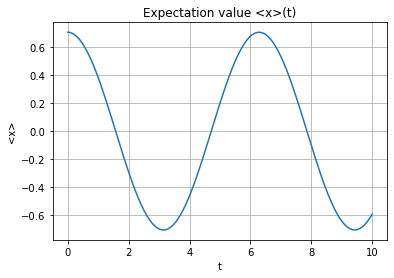

In [2]:
# grid
L = 20
N = 401
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Hamiltonian
T = cqd.hamiltonians.H_kinetic(x)
V = cqd.hamiltonians.HO_potential(x)
H = T + V

# diagonalize
E, psi = LA.eigh(H)

# normalize properly
psi = psi / np.sqrt(dx)

psi0 = (psi[:,0] + psi[:,1]) / np.sqrt(2)
def psi_t(t):
    return (psi[:,0]*np.exp(-1j*E[0]*t) +
            psi[:,1]*np.exp(-1j*E[1]*t))/np.sqrt(2)
    
times = np.linspace(0,10,200)
x_expect = []

for t in times:
    psi_now = psi_t(t)
    rho = np.abs(psi_now)**2
    x_expect.append(np.sum(x*rho)*dx)

plt.figure()
plt.plot(times, x_expect)
plt.xlabel("t")
plt.ylabel("<x>")
plt.title("Expectation value <x>(t)")
plt.grid()
plt.show()

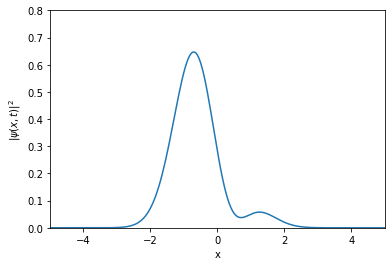

In [3]:
fig, ax = plt.subplots()

# axis settings (important!)
ax.set_xlim(-5, 5)
ax.set_ylim(0, 0.8)
ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi(x,t)|^2$")

line, = ax.plot([],[])
# add more axis specifications here, e.g. axis limits

def animate(t):
    # y = ... # in this line you should assign current wave function to y at time t, x is the vector of grid points (to be defined!)
    psi_now = psi_t(t)           # time-evolved wavefunction
    y = np.abs(psi_now)**2       # probability density
    line.set_data(x, y)
    return (line,)

anim = animation.FuncAnimation(
    fig,
    animate,
    frames=np.arange(0,10,0.1), # t-values
    interval=50,  # wait time before displaying new frame in ms
    blit=True
)

HTML(anim.to_jshtml())

- Solve the eigenvalue problem

In [4]:
from numpy import linalg as LA   # diagonalization and more

- Time evolution of superpositions

- Animate the solutions

- Compute the expectation value of x

### Exercise 2

Calculate the time evolution for arbitrary initial states by decomposing them into a superposition of eigenstates. Test your implementation for a coherent state, i.e. a Gaussian state that is shifted by $x_0$:
$$
\psi_0(x) = \frac{1}{\pi^{1/4}}e^{-(x-x_0)^2/2}
$$
Again, animate the resulting dynamics and also calculate the expectation value of x as a function of time. Describe and interpret your observations.

**Optional**: Play with other initial conditions and other potentials. For example take the double well potential from problem sheet 1 and initialize the system in a state localized on one side. What happens? How do the dynamics depend on the barrier height, i.e. on $\lambda$? Also instructive: Build up the coherent state by taking into account more and more of the eigenstates in the initial superposition and observe what happens to the time evolution.

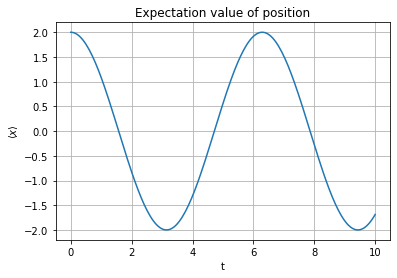

In [ ]:
#Grid 
L = 20
N = 401
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

#Hamiltonian
T = cqd.hamiltonians.H_kinetic(x)
V = cqd.hamiltonians.HO_potential(x)
H = T + V

# diagonalize
E, psi = eigh(H)

# normalize eigenfunctions
psi = psi / np.sqrt(dx)


#Initial coherent state
x0 = 2.0
psi_init = np.exp(-(x - x0)**2 / 2)
psi_init /= np.sqrt(np.sum(np.abs(psi_init)**2) * dx)


#Expansion coefficients
coeff = psi.conj().T @ psi_init * dx


#Time evolution
def psi_t(t):
    return psi @ (coeff * np.exp(-1j * E * t))

#Expectation value <x>
times = np.linspace(0, 10, 200)

x_expect = [
    np.sum(x * np.abs(psi_t(t))**2) * dx
    for t in times
]

plt.figure()
plt.plot(times, x_expect)
plt.xlabel("t")
plt.ylabel(r"$\langle x \rangle$")
plt.title("Expectation value of position")
plt.grid()
plt.show()

#Animation
fig, ax = plt.subplots()
ax.set_xlim(-6, 6)
ax.set_ylim(0, 0.6)
ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi(x,t)|^2$")

line, = ax.plot([], [])

def animate(t):
    y = np.abs(psi_t(t))**2
    line.set_data(x, y)
    return (line,)

anim = animation.FuncAnimation(
    fig,
    animate,
    frames=np.arange(0, 10, 0.1),
    interval=50,
    blit=True
)

HTML(anim.to_jshtml())


### Exercise 3

How does the runtime scale with the basis size (number of grid points)? Increase the number of gridpoints from 101 to 1601 in steps of 100 and record the time needed for the exact diagonalization. Plot the runtime as a function of basis size on a double logarithmic scale. Also try out the routine `scipy.linalg.eigh_tridiagonal()` and compare its runtime to `np.eigh()`.

The purpose of this exercise is to sensibilize you that using routines that take into account as much information about the problem to be solved can be a huge advantage in terms of computation time.
The outcome may vary depending on the machine you are using. You are encouraged to explore the documentation of the respective functions and find out what kind of routines they are using underneath.

**Hints**: You can e.g. use the "time" module you can measure the time it takes to do the diagonalization (see code snippet below).

In [ ]:
# grid sizes
L = 20
sizes = np.arange(101, 1601, 100)
runtime_dense = []
runtime_tridiag = []

for N in sizes:
    x = np.linspace(-L/2, L/2, N)
    dx = x[1] - x[0]

    H_pot = cqd.hamiltonians.HO_potential(x)
    H_kin = cqd.hamiltonians.H_kinetic(x)
    H_mat = H_pot + H_kin

    # dense
    t0 = time.perf_counter()
    E = eigh(H_mat, eigvals_only=True)
    t1 = time.perf_counter()
    runtime_dense.append(t1 - t0)

    # tridiagonal extracted from same matrix
    main_diag = np.diag(H_mat)
    off_diag = np.diag(H_mat, k=1)

    t0 = time.perf_counter()
    E_tri = eigh_tridiagonal(main_diag, off_diag, eigvals_only=True)
    t1 = time.perf_counter()
    runtime_tridiag.append(t1 - t0)

# Plot (log-log)

plt.figure()
plt.loglog(sizes, runtime_dense, 'o-', label="np.eigh (dense)")
plt.loglog(sizes, runtime_tridiag, 's-', label="eigh_tridiagonal")
plt.xlabel("Number of grid points N")
plt.ylabel("Runtime (s)")
plt.title("Runtime scaling of diagonalization")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [ ]:
# grid sizes
L = 20
sizes = np.arange(101, 1601, 100)
runtime_dense = []
runtime_tridiag = []
for N in sizes:
    x = np.linspace(-L/2, L/2, N)
    dx = x[1] - x[0]

    # Build Hamiltonian (dense)
    H_pot = cqd.hamiltonians.HO_potential(x)
    H_kin = cqd.hamiltonians.H_kinetic(x)
    H_mat = H_pot + H_kin

    # Dense diagonalization 
    t0 = time.time()
    E, psi = eigh(H_mat)
    t1 = time.time()
    runtime_dense.append(t1 - t0)

    # -Tridiagonal form -
    main_diag = 1/dx**2 + 0.5 * x**2
    off_diag = -0.5 * np.ones(N-1) / dx**2

    # Tridiagonal diagonalization
    t0 = time.time()
    E_tri = eigh_tridiagonal(main_diag, off_diag)[0]
    t1 = time.time()
    runtime_tridiag.append(t1 - t0)


# Plot (log-log)

plt.figure()
plt.loglog(sizes, runtime_dense, 'o-', label="np.eigh (dense)")
plt.loglog(sizes, runtime_tridiag, 's-', label="eigh_tridiagonal")
plt.xlabel("Number of grid points N")
plt.ylabel("Runtime (s)")
plt.title("Runtime scaling of diagonalization")
plt.legend()
plt.grid(True, which="both")
plt.show()

- Runtime analysis

- Interpretation: ...

### Exercise 4

Since our Hamiltonian matrix contains a lot of zeros it makes sense to use sparse matrices. Hamiltonian matrices of physical systems are very often sparse. If we are only interested in the low lying eigenstates, the Lanczos algorithm provides a very efficient way of obtaining those. Calculate the lowest (e.g. 20) eigenvalues, using sparse matrices. Compare the runtime to your previous implementations. For diagonalising a sparse symmetric matrix, you can use `scipy.sparse.linalg.eigsh()`

- Does the observed scaling of the runtime match your expectations? Again the outcome may depend on the hardware you are using.

**Hints**: For building the Hamiltonian as a sparse matrix, the function `scipy.sparse.diags()` might be helpful. Think about what the "which" option of `scipy.sparse.linalg.eigsh()` should be set to.

In [ ]:
# grid sizes
sizes = np.arange(101, 1601, 100)
runtime_sparse = []
L = 20
for N in sizes:
    x = np.linspace(-L/2, L/2, N)
    dx = x[1] - x[0]

#Build sparse Hamiltonian
    main_diag = 1/dx**2 + 0.5 * x**2
    off_diag = -0.5 * np.ones(N-1) / dx**2
    H_sparse = diags(
        [off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        format='csr'
    )

#Lanczos diagonalization 
    t0 = time.time()

    E_sparse, psi_sparse = eigsh(
        H_sparse,
        k=20,          # lowest 20 eigenvalues
        which='SM'     # smallest magnitude eigenvalues
    )

    t1 = time.time()
    runtime_sparse.append(t1 - t0)


# Plot runtime
plt.figure()
plt.loglog(sizes, runtime_sparse, 'o-', label="eigsh (sparse Lanczos)")
plt.xlabel("Number of grid points N")
plt.ylabel("Runtime (s)")
plt.title("Runtime scaling (sparse Lanczos)")
plt.legend()
plt.grid(True, which="both")
plt.show()